# FigureSI_ — Motion blur analysis

*Makes up Figures S45–S50.*

Quantifies the effect of translational motion blur on localisation precision, colour
precision, and PSF ellipticity, using the elliptical fitting strategy
(`FittingStrategy.ELLIPTICAL`), which recovers separate `s_x`/`s_y`/`theta` per localisation
so blur-induced PSF elongation is captured directly rather than averaged into a wider
circular sigma.

**Motion model:** constant velocity in a random direction during a 100 ms frame exposure;
per-frame displacement = velocity x 0.1 s, a fresh random direction each frame.

**Structure**
1. PSF shape visualisation — Gaussian PSF at increasing motion-blur displacement, on both a
   plain grid and the Bayer detector, plus exemplar noisy `ELLIPTICAL` fits for a sanity check.
2. Velocity-sweep simulation — N velocities x 3 photon levels x 3 dyes.
3. Analysis — localisation precision, colour precision, PSF ellipticity, and fit bias vs.
   velocity/displacement, plus fold-degradation-vs-no-blur summary surfaces.

**`FAST_MODE` flag:** `True` (default) sweeps 8 velocities x ~12 photon levels x 100
bootstrap fits per condition instead of the published 50 velocities x 100 photon levels x
10,000 bootstrap fits — same 3 dyes, so the same comparison, just coarser and noisier, in a
few minutes rather than the original HPC-scale run. `FAST_MODE = False` reproduces the
published sweep exactly.

In [1]:
import glob
import time
import types
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import xarray as xr
from scipy.spatial.distance import cdist

from pyS3M import IOFunctions, SpectralFunctions, MaskFunctions, sCMOSFunctions, PlottingBase
from pyS3M.simulation.multicolour import (
    MultiC_Sim_Funcs, FittingStrategy, SimulationConfig, CameraParameters, MultiC_Sim_Funcs_Refactored,
)
import pyS3M.gaussoptfuncs as gaussoptfuncs

IO = IOFunctions.IO_Functions()
S_F = SpectralFunctions.Spectral_Funcs()
M_F = MaskFunctions.Mask_Functions()
sCMOS = sCMOSFunctions.sCMOS_Functions()
MSF = MultiC_Sim_Funcs()
plotter = PlottingBase.PublicationPlotter()
fs = plotter.config.font_size

REPO_ROOT = Path.cwd().resolve().parents[2]
CALIBRATION_DIR = REPO_ROOT / "Camera_Calibrations" / "Ximea_Camera"
OUT_ROOT = Path("outputs") / "MotionBlur_Analysis"  # git-ignored

FAST_MODE = True  # False -> the published 50-velocity / 100-photon-level / 10,000-bootstrap sweep
print(f"FAST_MODE={FAST_MODE}")

FAST_MODE=True


## Camera calibration & spectral setup

In [2]:
gain = IO.read_tiff(str(CALIBRATION_DIR / "gain.tif"))
offset = IO.read_tiff(str(CALIBRATION_DIR / "offset.tif"))
variance = IO.read_tiff(str(CALIBRATION_DIR / "variance.tif"))
readnoise = float(np.median(IO.read_tiff(str(CALIBRATION_DIR / "readnoise.tif"))))
rqe = IO.read_tiff(str(CALIBRATION_DIR / "rqe.tif"))

R, G, B, wavelength = S_F.getpixelefficiency()
pixel_QYs = np.vstack([B, G, R])  # (3, n_wl); convention B=0, G=1, R=2

dyes = ["ATTO 488", "ATTO 565", "ATTO 647N"]
filters = []
NA = 1.49
pixel_size_nm = 69.0
image_dims = 22  # 22x22 px -- larger than the other SI notebooks' 14px, to fit blur-elongated PSFs
background_photons = 5.0
frame_exposure_ms = 100.0

smoothing_function = types.SimpleNamespace(
    args={"sigma": 1.5}, extent=1.5,
    smoothing_function=sCMOS.gaussian_filter_stack, data_arg="image",
)

OUT_ROOT.mkdir(parents=True, exist_ok=True)
print(f"Wavelength grid: {wavelength[0]:.0f}-{wavelength[-1]:.0f} nm ({len(wavelength)} pts)")

Wavelength grid: 400-999 nm (600 pts)


In [3]:
def make_camera_params(dims):
    return {
        "gain": np.full((dims, dims), np.median(gain)),
        "offset": np.full((dims, dims), np.median(offset)),
        "variance": np.full((dims, dims), np.median(variance)),
        "readnoise": readnoise,
        "rqe": np.full((dims, dims), np.median(rqe)),
        "masks": M_F.get_masks(size_x=dims, size_y=dims),
        "pixel_QYs": pixel_QYs,
        "pixel_order": ["B", "G", "R"],
        "pixel_order_indices": {"B": 0, "G": 1, "R": 2},
    }


camera_params_dict = make_camera_params(image_dims)
print(f"Camera parameters ready -- image size: {image_dims}x{image_dims} px")

Camera parameters ready -- image size: 22x22 px


## Figure 1: PSF shape under motion blur

Time-integrated Gaussian PSF at increasing displacement (velocity x 100 ms exposure). No
noise, no camera effects — shows the pure effect of the motion-blur kernel.

In [4]:
pix_vis_nm = 10.0     # 10 nm/px oversampling
psf_size_vis = 201    # 2.01 um window
sigma_vis_nm = 120.0  # approximate Gaussian sigma for a 488 nm dye, NA 1.49

displacements_nm = np.array([0, 100, 250, 500, 1000], dtype=float)
n_disp = len(displacements_nm)

_cx = psf_size_vis / 2.0
xx, yy = np.meshgrid(np.arange(psf_size_vis), np.arange(psf_size_vis), indexing="ij")
sigma_px = sigma_vis_nm / pix_vis_nm


def _gauss_fn(x0, y0, _n):
    g = np.exp(-((xx - x0) ** 2 + (yy - y0) ** 2) / (2 * sigma_px ** 2))
    return (g / g.sum()).astype(np.float32)


psf_vis_stack = []
np.random.seed(42)
for d_nm in displacements_nm:
    d_px = d_nm / pix_vis_nm
    if d_px == 0.0:
        psf_vis_stack.append(_gauss_fn(_cx, _cx, None))
    else:
        angle = np.random.uniform(0, 2 * np.pi)
        psf_vis_stack.append(
            MultiC_Sim_Funcs_Refactored._apply_motion_blur(
                _gauss_fn, np.array([_cx]), np.array([_cx]), np.array([1]), d_px, angle, n_samples=51,
            )
        )

print(f"Computed {n_disp} PSF images (pixel size {pix_vis_nm} nm, sigma = {sigma_vis_nm} nm)")

Computed 5 PSF images (pixel size 10.0 nm, sigma = 120.0 nm)


/tmp/ipykernel_1030303/3776193150.py:13: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0.05)


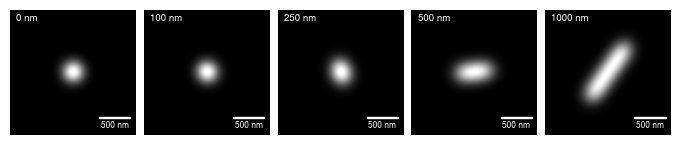

In [5]:
fig, axs = plotter.two_column_plot(nrows=1, ncols=n_disp, height=6.69 / n_disp + 0.1)

for i_d, (d_nm, psf) in enumerate(zip(displacements_nm, psf_vis_stack)):
    I_disp = psf / psf.max()
    plotter.image_plot(
        axs[i_d], I_disp, cmap="gray", vmin=np.percentile(I_disp, 1), vmax=np.percentile(I_disp, 99.9),
        scalebar=True, pixelsize=pix_vis_nm, scalebarsize=500.0, scalebarlabel="500 nm",
        scalebar_color="white", origin="lower", colorbar=False,
    )
    label = f"{d_nm:.0f} nm" if d_nm > 0 else "0 nm"
    axs[i_d].text(0.05, 0.97, label, transform=axs[i_d].transAxes, fontsize=fs, color="white", va="top", ha="left")

fig.subplots_adjust(wspace=0.05)
plt.show()

## Figure 1b: motion-blur PSFs on the Bayer detector — 3 dyes x 5 displacements

Each detector pixel only receives light through its own Bayer colour filter, so the detected
image has the characteristic checkerboard brightness pattern. The dye-pixel efficiency (DPE)
— integral of (emission x channel QY) — sets how bright B/G/R pixels are relative to each
other for each dye.

ATTO 488      B=0.143  G=0.744  R=0.113
ATTO 565      B=0.028  G=0.389  R=0.583


ATTO 647N     B=0.065  G=0.212  R=0.723


/tmp/ipykernel_1030303/2412650266.py:59: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0.05, hspace=0.08)


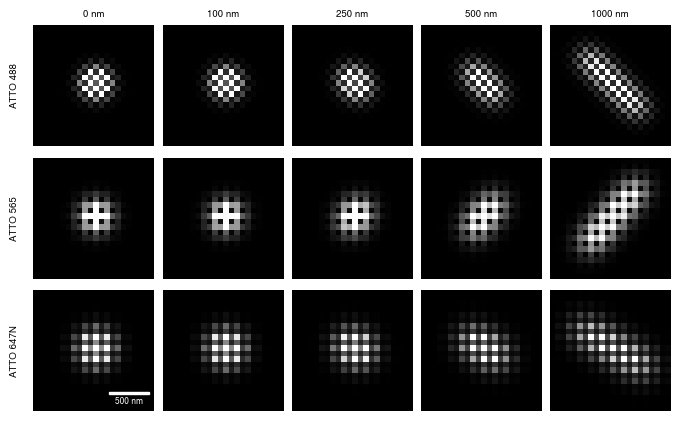

In [6]:
dye_dpe = {}
for dye in dyes:
    dye_spec = S_F.get_dye_or_filter_data(names=[dye], wavelength=wavelength, dye_or_filter=True)[0]
    ch_totals = np.array([np.trapz(dye_spec * pixel_QYs[i], wavelength) for i in range(3)])  # B=0, G=1, R=2
    dye_dpe[dye] = ch_totals / ch_totals.sum()
    print(f"{dye:12s}  B={dye_dpe[dye][0]:.3f}  G={dye_dpe[dye][1]:.3f}  R={dye_dpe[dye][2]:.3f}")

masks_det = M_F.get_masks(size_x=image_dims, size_y=image_dims)
mask_B, mask_G, mask_R = masks_det["B"].astype(float), masks_det["G"].astype(float), masks_det["R"].astype(float)

pix_det_nm = pixel_size_nm
_cx_det = image_dims / 2.0
xx_det, yy_det = np.meshgrid(np.arange(image_dims), np.arange(image_dims), indexing="ij")

dye_emission_nm = {"ATTO 488": 520.0, "ATTO 565": 590.0, "ATTO 647N": 669.0}
dye_sigma_det = {d: 120.0 * dye_emission_nm[d] / 520.0 for d in dyes}
dye_seeds = {"ATTO 488": 42, "ATTO 565": 43, "ATTO 647N": 44}

bayer_psf_stacks = {}
for dye in dyes:
    sig_px = dye_sigma_det[dye] / pix_det_nm
    np.random.seed(dye_seeds[dye])
    angle = np.random.uniform(0, 2 * np.pi)
    B_frac, G_frac, R_frac = dye_dpe[dye]

    def _gauss_det(x0, y0, _n, _sig=sig_px):
        g = np.exp(-((xx_det - x0) ** 2 + (yy_det - y0) ** 2) / (2 * _sig ** 2))
        return (g / g.sum()).astype(np.float32)

    stack = []
    for d_nm in displacements_nm:
        d_px = d_nm / pix_det_nm
        if d_px == 0.0:
            psf = _gauss_det(_cx_det, _cx_det, None)
        else:
            psf = MultiC_Sim_Funcs_Refactored._apply_motion_blur(
                _gauss_det, np.array([_cx_det]), np.array([_cx_det]), np.array([1]), d_px, angle, n_samples=51,
            )
        bayer_im = psf * (B_frac * mask_B + G_frac * mask_G + R_frac * mask_R)
        stack.append(bayer_im / bayer_im.max() if bayer_im.max() > 0 else bayer_im)
    bayer_psf_stacks[dye] = stack

n_rows, n_cols = len(dyes), n_disp
fig, axs = plotter.two_column_plot(nrows=n_rows, ncols=n_cols, height=n_rows * (6.69 / n_cols) + 0.1)

for i_row, dye in enumerate(dyes):
    for i_col, (d_nm, bayer_im) in enumerate(zip(displacements_nm, bayer_psf_stacks[dye])):
        ax = axs[i_row, i_col]
        plotter.image_plot(
            ax, bayer_im, cmap="gray", interpolation="nearest",
            scalebar=(i_row == n_rows - 1 and i_col == 0), pixelsize=pix_det_nm,
            scalebarsize=500.0, scalebarlabel="500 nm", scalebar_color="white", origin="lower", colorbar=False,
        )
        if i_row == 0:
            ax.set_title(f"{d_nm:.0f} nm" if d_nm > 0 else "0 nm", fontsize=fs)
        if i_col == 0:
            ax.text(-0.12, 0.5, dye, transform=ax.transAxes, fontsize=fs, va="center", ha="right", rotation=90)

fig.subplots_adjust(wspace=0.05, hspace=0.08)
plt.show()

## Figure 1c: exemplar ELLIPTICAL fits for the Figure 1b data

Figure 1b above shows idealised, noiseless motion-blur PSFs. Here, for the same 3 dyes x 5
displacements, actually simulate (with real photon and read noise, plus camera calibration)
one example punctum per combination and fit it with `FittingStrategy.ELLIPTICAL` — the same
strategy used in the velocity sweep below — so the idealised PSF shapes above can be compared
against what the production fitting pipeline actually recovers (raw / fit / residual, plus
the fitted blur angle `theta`) at a representative photon/background level.

In [7]:
EXAMPLE_N_PHOTON = 4000.0  # representative photon count (mid-range of the sweep below)
EXAMPLE_BG = background_photons

cam_params_dc_ex = CameraParameters.validate_and_create(camera_params_dict)
x_arr_ex = np.arange(image_dims, dtype=np.float32)

exemplar_fits = {}  # (dye, displacement_nm) -> dict of raw/model/residual/xc/yc/theta/chi_sqr

for dye in dyes:
    aew_ex, dpe_ex = S_F.get_pixel_fractions_dye_and_filters([dye], filters, wavelength, pixel_QYs)
    x0_ex = y0_ex = image_dims * pixel_size_nm / 2.0

    for d_nm in displacements_nm:
        velocity_nm_s = d_nm / (frame_exposure_ms / 1000.0)

        # A single-shot (n_bootstrap=1) fit can occasionally fail the amplitude-SNR gate on an
        # unlucky Poisson-noise draw (no averaging to smooth it over) -- retry with a fresh
        # random draw a few times rather than showing a blank panel.
        MAX_ATTEMPTS = 5
        row = None
        for attempt in range(MAX_ATTEMPTS):
            n_photons_ex = {dye: np.array([EXAMPLE_N_PHOTON])}
            x0y0_ex = {dye: np.zeros((1, 2, 1))}
            x0y0_ex[dye][:, 0, 0] = x0_ex
            x0y0_ex[dye][:, 1, 0] = y0_ex

            bayer_ex, smoothed_ex, _ = MSF.gen_camera_image_stack(
                camera_params_dict, wavelength, np.array(aew_ex), np.array(dpe_ex), n_photons_ex, x0y0_ex,
                smoothing_function=smoothing_function, background_photons=EXAMPLE_BG, NA=NA,
                pixel_size=pixel_size_nm, motion_velocity_nm_per_s=float(velocity_nm_s),
                frame_exposure_ms=frame_exposure_ms, return_normal_image=False,
            )
            if bayer_ex.ndim == 2:
                bayer_ex = bayer_ex[np.newaxis]
                smoothed_ex = smoothed_ex[np.newaxis]

            config_ex = SimulationConfig(
                n_bootstrap=1, background_photons=EXAMPLE_BG, NA=NA, pixel_size=pixel_size_nm,
                verbose=False, save_raw_results=False,
                motion_velocity_nm_per_s=float(velocity_nm_s), frame_exposure_ms=frame_exposure_ms,
            )

            pe_ex, sm_ex, gs_ex = MSF._prepare_fitting_data(bayer_ex, smoothed_ex, cam_params_dc_ex, FittingStrategy.ELLIPTICAL, config_ex)
            weights_ex, _ = MSF._compute_error_maps(sm_ex, None, cam_params_dc_ex)
            fit_df_ex = MSF._perform_fitting(FittingStrategy.ELLIPTICAL, pe_ex, sm_ex, weights_ex, gs_ex, cam_params_dc_ex, config_ex)

            row = fit_df_ex.iloc[0]
            if not row.isna().any():
                break
        else:
            print(f"  WARNING: {dye} d={d_nm:.0f}nm -- fit failed on all {MAX_ATTEMPTS} attempts; showing the last attempt as-is.")

        xc, yc, s_x, s_y, theta = row["xc"], row["yc"], row["s_x"], row["s_y"], row["theta"]
        A_abs = np.array([row["A_B"], row["A_G"], row["A_R"]]) * row["photons"]
        bg_abs = np.array([row["bg_B"], row["bg_G"], row["bg_R"]]) * row["background_photons"]

        # process_fit_results' ELLIPTICAL branch relabels the raw leastsq sigma_x/sigma_y into
        # (s_x, s_y) by swapping them (so s_x/s_y line up with the xc/yc convention used
        # elsewhere), but theta is NOT re-derived to match that swap -- it still describes
        # rotation relative to the ORIGINAL, unswapped (raw sigma_x, raw sigma_y) pairing, so
        # reconstructing the model for residual/display must pass (s_y, s_x, theta) here, not
        # (s_x, s_y, theta).
        gauss2d_ex = np.zeros((image_dims, image_dims), dtype=np.float32)
        gauss2d_ex = gaussoptfuncs.gaussian_unscaled_model_elliptical(gauss2d_ex, x_arr_ex, image_dims, xc, yc, s_y, s_x, theta)
        model_ex = np.zeros((image_dims, image_dims), dtype=np.float32)
        for c_idx, c in enumerate(camera_params_dict["pixel_order"]):
            m = camera_params_dict["masks"][c]
            model_ex[m] = A_abs[c_idx] * gauss2d_ex[m] + bg_abs[c_idx]

        exemplar_fits[(dye, d_nm)] = dict(raw=pe_ex[0], model=model_ex, residual=pe_ex[0] - model_ex, xc=xc, yc=yc, theta=theta, chi_sqr=row["chi_sqr"])

print(f"Computed {len(exemplar_fits)} exemplar ELLIPTICAL fits ({len(dyes)} dyes x {len(displacements_nm)} displacements, {EXAMPLE_N_PHOTON:.0f} ph, {EXAMPLE_BG:.0f} bg).")

Computed 15 exemplar ELLIPTICAL fits (3 dyes x 5 displacements, 4000 ph, 5 bg).


/tmp/ipykernel_1030303/235661267.py:29: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0.05, hspace=0.08)


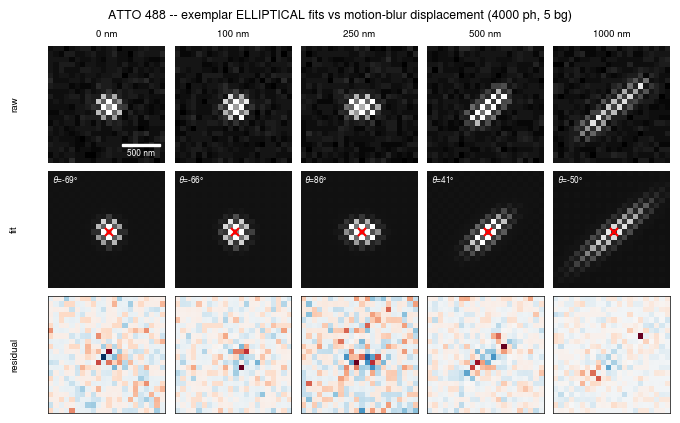

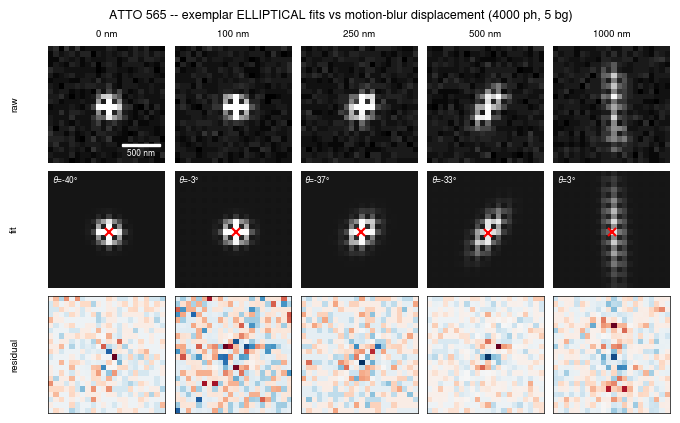

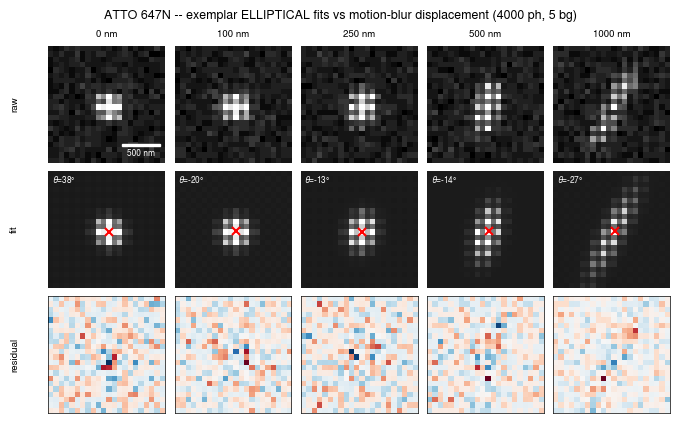

In [8]:
row_labels_ex = ["raw", "fit", "residual"]

for dye in dyes:
    fig, axs = plotter.two_column_plot(nrows=3, ncols=n_disp, height=3 * (6.69 / n_disp) + 0.1)

    raw_all = np.concatenate([exemplar_fits[(dye, d)]["raw"].ravel() for d in displacements_nm])
    vmin_ex, vmax_ex = np.percentile(raw_all, [1, 99])

    for i_col, d_nm in enumerate(displacements_nm):
        res = exemplar_fits[(dye, d_nm)]
        rmax = np.max(np.abs(res["residual"]))

        plotter.image_plot(axs[0, i_col], res["raw"], cmap="gray", vmin=vmin_ex, vmax=vmax_ex, colorbar=False, origin="upper",
                            scalebar=(i_col == 0), pixelsize=pixel_size_nm, scalebarsize=500.0, scalebarlabel="500 nm", scalebar_color="white")
        plotter.image_plot(axs[1, i_col], res["model"], cmap="gray", vmin=vmin_ex, vmax=vmax_ex, colorbar=False, origin="upper")
        axs[1, i_col].plot(res["xc"], res["yc"], "rx", markersize=6, markeredgewidth=1.5)
        # An ellipse is 180-degree periodic in theta -- wrap into a canonical (-90, 90] range for display.
        theta_deg = ((np.degrees(res["theta"]) + 90) % 180) - 90
        axs[1, i_col].text(0.03, 0.97, rf"$\theta$={theta_deg:.0f}$\degree$", transform=axs[1, i_col].transAxes, fontsize=6, color="white", ha="left", va="top")

        axs[2, i_col].imshow(res["residual"], cmap="RdBu_r", vmin=-rmax, vmax=rmax, origin="upper")
        axs[2, i_col].set_xticks([]); axs[2, i_col].set_yticks([])
        axs[0, i_col].set_title(f"{d_nm:.0f} nm" if d_nm > 0 else "0 nm", fontsize=fs)

    for i_row, lbl in enumerate(row_labels_ex):
        axs[i_row, 0].text(-0.25, 0.5, lbl, transform=axs[i_row, 0].transAxes, fontsize=fs, ha="right", va="center", rotation=90)

    fig.suptitle(f"{dye} -- exemplar ELLIPTICAL fits vs motion-blur displacement ({EXAMPLE_N_PHOTON:.0f} ph, {EXAMPLE_BG:.0f} bg)", fontsize=9)
    fig.subplots_adjust(wspace=0.05, hspace=0.08)
    plt.show()

## Velocity sweep simulation

For each (dye, velocity), run `test_simulation_method` with `FittingStrategy.ELLIPTICAL`
across several photon levels. Velocities span 0-10,000 nm/s -> displacements 0-1000 nm at
100 ms exposure (0-14.5 px at 69 nm/px).

In [9]:
n_velocities = 8 if FAST_MODE else 50
n_photon_steps = 12 if FAST_MODE else 100
n_bootstrap = 100 if FAST_MODE else 10_000

velocities_nm_per_s = np.linspace(0, 10000, n_velocities)
displacements_sweep_nm = velocities_nm_per_s * (frame_exposure_ms / 1000.0)
n_photon_space = np.geomspace(500, 20000, n_photon_steps)

print(f"Velocities (nm/s): {velocities_nm_per_s}")
print(f"Sweep: {len(dyes)} dyes x {len(velocities_nm_per_s)} velocities x {len(n_photon_space)} photon levels x {n_bootstrap} bootstrap")

Velocities (nm/s): [     0.           1428.57142857   2857.14285714   4285.71428571
   5714.28571429   7142.85714286   8571.42857143  10000.        ]
Sweep: 3 dyes x 8 velocities x 12 photon levels x 100 bootstrap


In [10]:
t_start = time.time()
n_total = len(dyes) * len(velocities_nm_per_s)
i_run = 0

for dye in dyes:
    for v_nm_s in velocities_nm_per_s:
        i_run += 1
        flag = f"motionblur_v{v_nm_s:06.0f}nms_"

        config = SimulationConfig(
            n_bootstrap=n_bootstrap, background_photons=background_photons, NA=NA, pixel_size=pixel_size_nm,
            save_raw_results=True, subtractx0y0=False, use_stochastic_photons=True, save_summary_csvs=True,
            verbose=False, motion_velocity_nm_per_s=float(v_nm_s), frame_exposure_ms=frame_exposure_ms,
        )

        disp_nm = v_nm_s * (frame_exposure_ms / 1000.0)
        print(f"[{i_run:3d}/{n_total}]  {dye}  v={v_nm_s:.0f} nm/s  (displacement {disp_nm:.0f} nm)", end="  ", flush=True)

        MSF.test_simulation_method(
            dye=dye, filters=filters, wavelength=wavelength, camera_parameters=camera_params_dict,
            save_folder=str(OUT_ROOT), n_photon_space=n_photon_space, smoothing_function=smoothing_function,
            strategy=FittingStrategy.ELLIPTICAL, starting_flag=flag, config=config, overwrite=True,
        )

        elapsed = (time.time() - t_start) / 60.0
        rate = i_run / elapsed if elapsed > 0 else 0
        eta = (n_total - i_run) / rate if rate > 0 else 0
        print(f"done ({elapsed:.1f} min elapsed, ETA {eta:.1f} min)")

print(f"\nSweep complete in {(time.time() - t_start) / 60:.1f} min.")

[  1/24]  ATTO 488  v=0 nm/s  (displacement 0 nm)  

INFO:pyS3M.simulation.multicolour:
Completed analysis of 12 photon flux values    Total time: 0.069 min


INFO:pyS3M.simulation.multicolour:Simulation completed for strategy elliptical


done (0.1 min elapsed, ETA 1.6 min)
[  2/24]  ATTO 488  v=1429 nm/s  (displacement 143 nm)  

INFO:pyS3M.simulation.multicolour:
Completed analysis of 12 photon flux values    Total time: 0.080 min


...

INFO:pyS3M.simulation.multicolour:Simulation completed for strategy elliptical


done (1.8 min elapsed, ETA 0.1 min)
[ 24/24]  ATTO 647N  v=10000 nm/s  (displacement 1000 nm)  

INFO:pyS3M.simulation.multicolour:
Completed analysis of 12 photon flux values    Total time: 0.080 min


INFO:pyS3M.simulation.multicolour:Simulation completed for strategy elliptical


done (1.9 min elapsed, ETA 0.0 min)

Sweep complete in 1.9 min.


## Analysis: precision + ellipticity

Load the RMSE summary CSVs and the raw HDF5 results. The raw results contain `theta` (fitted
blur angle) and separate `s_x`/`s_y`, which directly quantify the blur-induced PSF
ellipticity.

In [11]:
metrics = ["sigma_xy", "colour_dist", "ellipticity"]

da_motion = xr.DataArray(
    data=np.full([len(dyes), len(velocities_nm_per_s), len(n_photon_space), len(metrics)], np.nan),
    coords={"dye": dyes, "displacement_nm": displacements_sweep_nm, "n_photons": n_photon_space, "metric": metrics},
    dims=["dye", "displacement_nm", "n_photons", "metric"],
)

missing = []
for i_dye, dye in enumerate(dyes):
    dye_str = dye.replace("/", "-")
    for i_v, v_nm_s in enumerate(velocities_nm_per_s):
        flag = f"motionblur_v{v_nm_s:06.0f}nms_"

        pattern = str(OUT_ROOT / f"{flag}*{dye_str}*RMSE_mean*.csv")
        files = sorted(glob.glob(pattern))
        if not files:
            missing.append((dye, v_nm_s))
        else:
            df = pl.read_csv(files[0])
            for i_ph, r in enumerate(df.iter_rows(named=True)):
                da_motion[i_dye, i_v, i_ph, 0] = float(np.sqrt((r["xc"] ** 2 + r["yc"] ** 2) / 2))
                da_motion[i_dye, i_v, i_ph, 1] = float(r["colour_distance"])

        h5_path = OUT_ROOT / f"{flag}LM_method_{dye_str}_rawresults.h5"
        if h5_path.exists():
            try:
                df_raw = pd.read_hdf(str(h5_path), key="data")
                for i_ph in range(len(n_photon_space)):
                    subset = df_raw[df_raw["photon_level"] == i_ph]
                    if len(subset) == 0:
                        continue
                    sx = subset["s_x"].dropna().to_numpy() * pixel_size_nm
                    sy = subset["s_y"].dropna().to_numpy() * pixel_size_nm
                    s_maj, s_min = np.maximum(sx, sy), np.minimum(sx, sy)
                    with np.errstate(divide="ignore", invalid="ignore"):
                        ell = np.where(s_min > 0, s_maj / s_min, np.nan)
                    da_motion[i_dye, i_v, i_ph, 2] = float(np.nanmedian(ell))
            except Exception as e:
                print(f"  Could not load {h5_path.name}: {e}")

if missing:
    print(f"Missing RMSE files: {missing}")
da_motion.to_netcdf(str(OUT_ROOT / "motionblur_sweep.nc"))
print(f"DataArray shape: {da_motion.shape} -> saved motionblur_sweep.nc")
print(f"sigma_xy range: {float(da_motion.sel(metric='sigma_xy').min()):.1f}-{float(da_motion.sel(metric='sigma_xy').max()):.1f} nm")
print(f"ellipticity: {float(da_motion.sel(metric='ellipticity').min()):.3f}-{float(da_motion.sel(metric='ellipticity').max()):.3f}")

DataArray shape: (3, 8, 12, 3) -> saved motionblur_sweep.nc
sigma_xy range: 0.0-850.0 nm
ellipticity: 1.011-4.494


## Figure 2: localisation & colour precision vs displacement / photon count

Two complementary views of the same `sigma_xy`/`colour_dist` data: precision vs displacement
(one line per photon level) and precision vs photon count (one line per displacement).

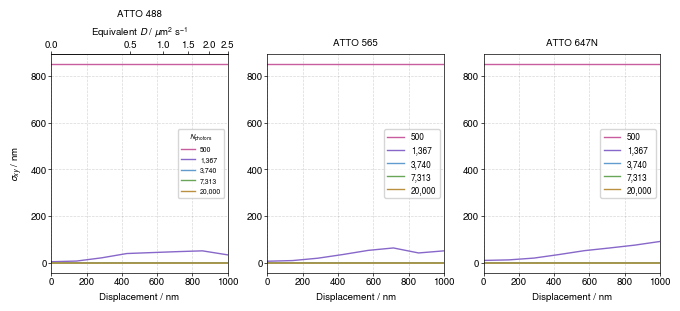

In [12]:
dye_labels = {d: d for d in dyes}
ph_sel = [n_photon_space[i] for i in np.linspace(0, len(n_photon_space) - 1, 5).round().astype(int)]
colors = ["#cb584d", "#bb903e", "#69a657", "#619cce", "#8767c9", "#c75d9e"][::-1]
T_exp_s = frame_exposure_ms / 1000.0

fig, axs = plotter.two_column_plot(nrows=1, ncols=len(dyes), width_ratios=np.ones(len(dyes)))
for i_c, dye in enumerate(dyes):
    ax = axs[i_c]
    Z = da_motion.isel(dye=i_c).sel(metric="sigma_xy").values  # (n_disp, n_photons)
    for val, ph in enumerate(ph_sel):
        ind = np.argmin(np.abs(n_photon_space - ph))
        ax = plotter.line_plot(ax, displacements_sweep_nm, Z[:, ind], color=colors[val], label=f"{ph:,.0f}")
    ax.set_xlabel("Displacement / nm", fontsize=fs)
    ax.set_ylabel(r"$\sigma_{xy}$ / nm" if i_c == 0 else "", fontsize=fs)
    ax.set_title(dye_labels[dye], fontsize=fs)
    ax.set_xlim([displacements_sweep_nm[0], displacements_sweep_nm[-1]])
    if i_c == 0:
        ax.legend(title=r"$N_\mathrm{photons}$", fontsize=fs - 2, title_fontsize=fs - 2)
        ax2 = ax.secondary_xaxis("top", functions=(
            lambda d, T=T_exp_s: d ** 2 / (4 * T * 1e6),
            lambda D, T=T_exp_s: np.sqrt(np.maximum(D, 0) * 4 * T * 1e6),
        ))
        ax2.set_xlabel(r"Equivalent $D$ / $\mu$m$^{2}$ s$^{-1}$", fontsize=fs)

plt.show()

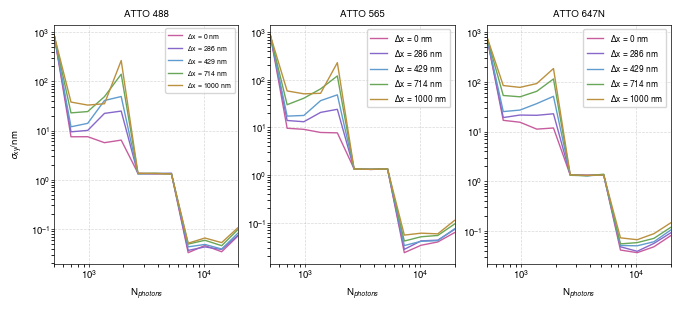

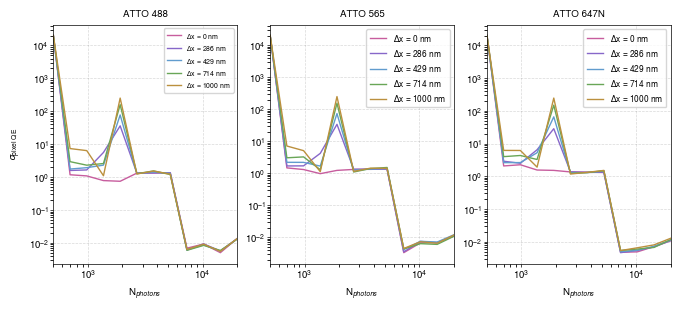

In [13]:
# Displacements picked for the "vs photon count" lines below -- nearest actually-simulated
# value to each of these targets.
displacements_sel = [0, displacements_sweep_nm.max() * 0.25, displacements_sweep_nm.max() * 0.5,
                      displacements_sweep_nm.max() * 0.75, displacements_sweep_nm.max()]

for metric, ylabel, ylim in [
    ("sigma_xy", r"$\sigma_{\mathrm{xy}}$/nm", None),
    ("colour_dist", r"$\sigma_{\mathrm{pixel\ QE}}$", None),
]:
    fig, axs = plotter.two_column_plot(nrows=1, ncols=len(dyes), width_ratios=np.ones(len(dyes)))
    for i_c, dye in enumerate(dyes):
        ax = axs[i_c]
        Z = da_motion.isel(dye=i_c).sel(metric=metric).values  # (n_disp, n_photons)
        for val, D in enumerate(displacements_sel):
            ind = np.argmin(np.abs(displacements_sweep_nm - D))
            ax = plotter.line_plot(ax, n_photon_space, Z[ind, :], color=colors[val], label=f"$\\Delta$x = {displacements_sweep_nm[ind]:.0f} nm")
        ax.set_yscale("log"); ax.set_xscale("log")
        ax.set_xlabel(r"N$_{photons}$", fontsize=fs)
        ax.set_ylabel(ylabel if i_c == 0 else "", fontsize=fs)
        ax.set_title(dye_labels[dye], fontsize=fs)
        ax.set_xlim([np.min(n_photon_space), np.max(n_photon_space)])
        if ylim:
            ax.set_ylim(ylim)
        if i_c == 0:
            ax.legend(fontsize=fs - 2)
    plt.show()

## Next steps

Set `FAST_MODE = False` above and re-run for the published sweep (50 velocities x 100
photon levels x 10,000 bootstrap fits x 3 dyes — an HPC-scale run, expect a long time and a
large `outputs/MotionBlur_Analysis/` directory of intermediate HDF5/CSV files, git-ignored).